<a href="https://colab.research.google.com/github/devireddyajay/Heart-Stroke-Risk-Analysis-Across-Age-Groups/blob/main/Heart_Stroke_Risk_Analysis_Across_Age_Groups.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import all libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.patches as patches
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.font_manager import FontProperties

displays top 5rows of a dataframe

In [35]:
heartstrokedata = pd.read_csv("/content/healthcare-dataset-stroke-data.csv")
heartstrokedata.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Creates a new copy of the heartstrokedata dataframe and stores it in a new variable called heartdf.

In [36]:
heartdf=  heartstrokedata.copy()

it gives summary of a dataframe

In [37]:
heartdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB



It shows  how many missing values  are in each column of the dataframe

In [38]:
heartdf.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


shows the datatypes of all available columns in a dataframe

In [39]:
heartdf.dtypes

,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64



It helps us to detect which columns have missing values and how many,And see where missing values appear across the dataset rows.


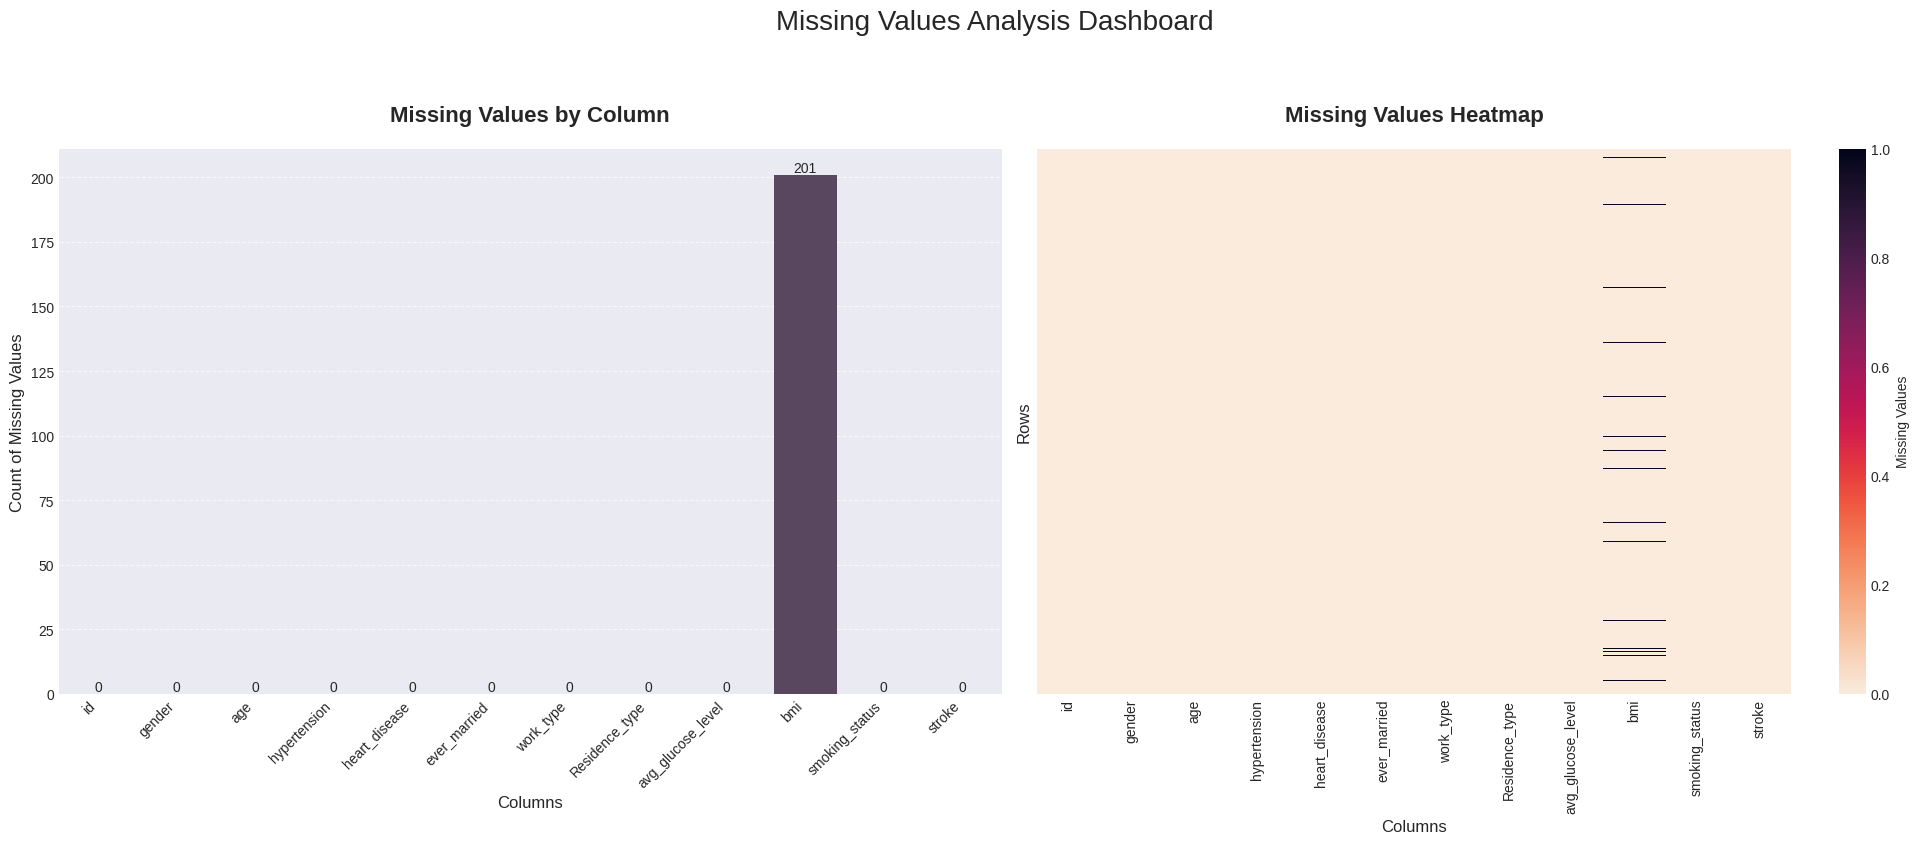

In [40]:
fig = plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
missing_values = heartdf.isnull().sum()
ax = sns.barplot(x=missing_values.index, y=missing_values.values, alpha=0.8, color='#35193e')
plt.title('Missing Values by Column', pad=20, fontsize=16, fontweight='bold')
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Count of Missing Values', fontsize=12)
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(missing_values.values):
    ax.text(i, v, str(v), ha='center', va='bottom')

ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.heatmap(heartdf.isnull(),
            cmap='rocket_r',
            yticklabels=False,
            cbar_kws={'label': 'Missing Values'})
plt.title('Missing Values Heatmap', pad=20, fontsize=16, fontweight='bold')
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Rows', fontsize=12)

plt.suptitle('Missing Values Analysis Dashboard', fontsize=20, y=1.05)
plt.tight_layout()

plt.show()

it formats all column names in the dataframe by capitalizes the first letter of each word and lowers the rest.

In [41]:
heartdf.columns = heartdf.columns.str.title()
heartdf.columns

Index(['Id', 'Gender', 'Age', 'Hypertension', 'Heart_Disease', 'Ever_Married',
       'Work_Type', 'Residence_Type', 'Avg_Glucose_Level', 'Bmi',
       'Smoking_Status', 'Stroke'],
      dtype='object')

defineing age categories

In [42]:
def agecategories(age):
    if age >= 0 and age <= 1:
        return 'School Age'
    elif age > 12 and age < 20:
        return 'Teenager'
    elif age >= 20 and age <= 24:
        return 'Youth'
    elif age > 24 and age <= 39:
        return 'Adult'
    elif age > 39 and age <= 55:
        return 'Middle Aged'
    else:
        return 'Senior'

creates a bar plot showing the distribution of different age groups in the dataset.


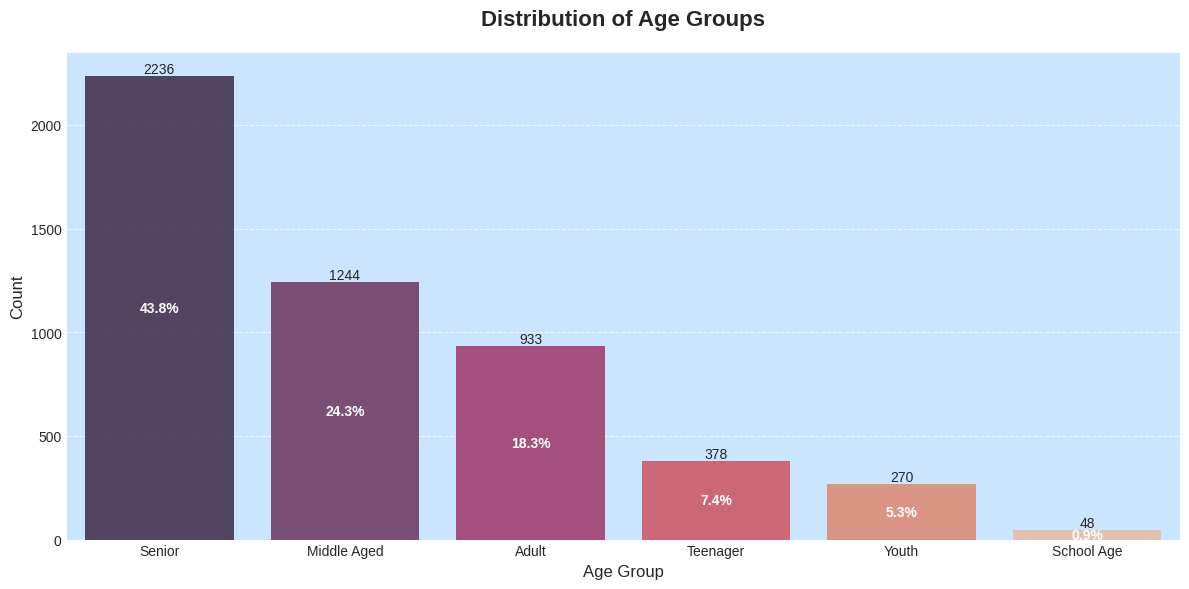

In [48]:
heartdf['Age_Group'] = heartdf['Age'].apply(agecategories)

plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(12, 6))

age_counts = heartdf['Age_Group'].value_counts()
ax = sns.barplot(x=age_counts.index,
                 y=age_counts.values,
                 palette='rocket',
                 alpha=0.8)

plt.title('Distribution of Age Groups', pad=20, fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Count', fontsize=12)

for i, v in enumerate(age_counts.values):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=10)

ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=0)

ax.set_facecolor('#cce5ff')

total = age_counts.sum()
for i, v in enumerate(age_counts.values):
    percentage = (v/total) * 100
    ax.text(i, v/2, f'{percentage:.1f}%',
            ha='center',
            va='center',
            color='white',
            fontweight='bold')

plt.tight_layout()

plt.show()


In [44]:
heartdf.duplicated().sum()

np.int64(0)

removes other gender

In [45]:
heartdf = heartdf[heartdf['Gender'] != 'Other']

displays genders

In [46]:
heartdf.Gender.value_counts()

,count
Gender,
Female,2994
Male,2115


identifies bmi values greater than 45

In [50]:
heartdf[heartdf['Bmi'] >= 45]

,Id,Gender,Age,Hypertension,Heart_Disease,Ever_Married,Work_Type,Residence_Type,Avg_Glucose_Level,Bmi,Smoking_Status,Stroke,Age_Group
21,13861,Female,52.0,1,0,Yes,Self-employed,Urban,233.29,48.9,never smoked,1,Middle Aged
66,17004,Female,70.0,0,0,Yes,Private,Urban,221.58,47.5,never smoked,1,Senior
79,42117,Male,43.0,0,0,Yes,Self-employed,Urban,143.43,45.9,Unknown,1,Middle Aged
113,41069,Female,45.0,0,0,Yes,Private,Rural,224.10,56.6,never smoked,1,Middle Aged
163,20426,Female,78.0,1,0,No,Private,Urban,203.87,45.7,never smoked,1,Senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4976,63656,Female,18.0,0,0,No,Private,Urban,101.95,46.0,formerly smoked,0,Teenager
5009,40732,Female,50.0,0,0,Yes,Self-employed,Rural,126.85,49.5,formerly smoked,0,Middle Aged
5015,50140,Female,44.0,0,0,Yes,Govt_job,Rural,133.24,45.0,smokes,0,Middle Aged
5057,38349,Female,49.0,0,0,Yes,Govt_job,Urban,69.92,47.6,never smoked,0,Middle Aged


In [53]:
Q1 = heartdf['Bmi'].quantile(0.25)
Q3 = heartdf['Bmi'].quantile(0.75)
IQR = Q3 - Q1

x = Q1 - 3 * IQR
y = Q3 + 3 * IQR

outliers = heartdf[(heartdf['Bmi'] < x) | (heartdf['Bmi'] > y)]
outliers

,Id,Gender,Age,Hypertension,Heart_Disease,Ever_Married,Work_Type,Residence_Type,Avg_Glucose_Level,Bmi,Smoking_Status,Stroke,Age_Group
358,66333,Male,52.0,0,0,Yes,Self-employed,Urban,78.40,64.8,never smoked,0,Middle Aged
544,545,Male,42.0,0,0,Yes,Private,Rural,210.48,71.9,never smoked,0,Middle Aged
928,41097,Female,23.0,1,0,No,Private,Urban,70.03,78.0,smokes,0,Youth
1559,37759,Female,53.0,0,0,Yes,Private,Rural,72.63,66.8,Unknown,0,Middle Aged
2128,56420,Male,17.0,1,0,No,Private,Rural,61.67,97.6,Unknown,0,Teenager
2764,20292,Female,24.0,0,0,Yes,Private,Urban,85.55,63.3,never smoked,0,Youth
4188,70670,Female,27.0,0,0,Yes,Private,Rural,57.96,64.4,never smoked,0,Adult
4209,51856,Male,38.0,1,0,Yes,Private,Rural,56.90,92.0,never smoked,0,Adult


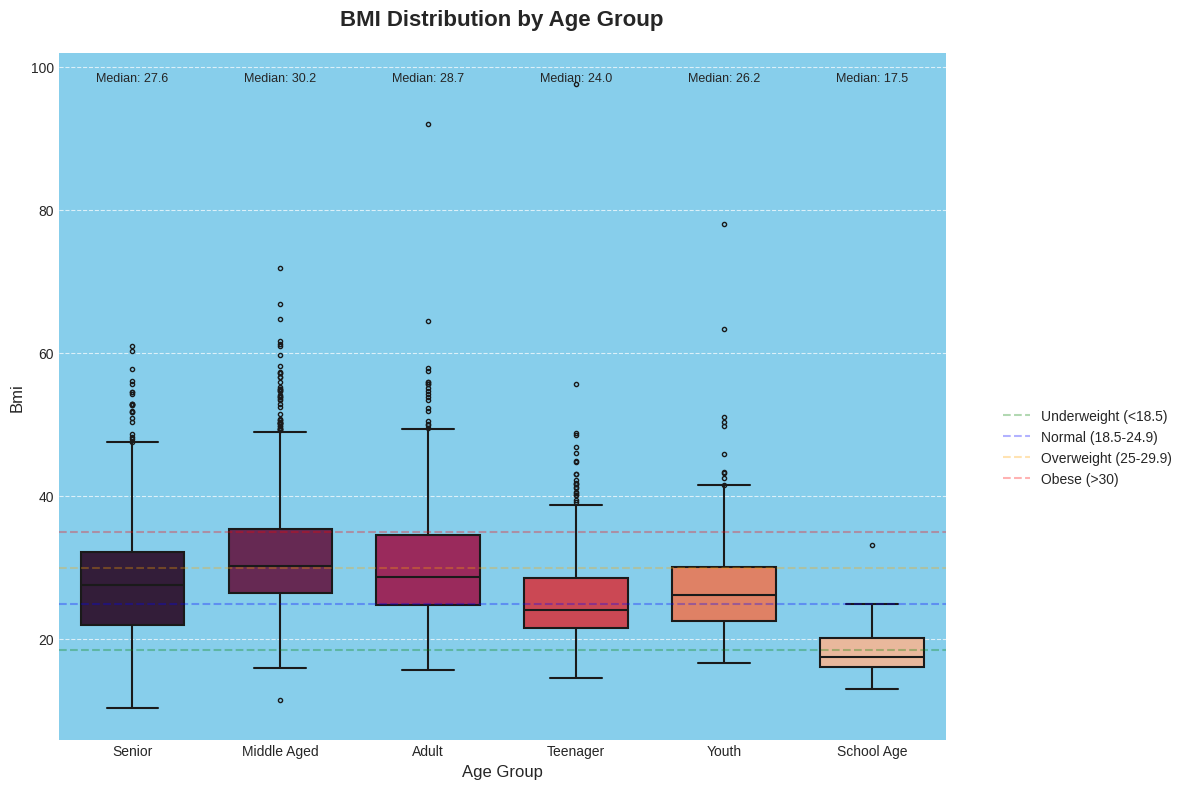

In [57]:
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(12, 8))


ax = sns.boxplot(data=heartdf,
                 x='Age_Group',
                 y='Bmi',
                 palette='rocket',
                 width=0.7,
                 fliersize=3,
                 linewidth=1.5)


plt.title('BMI Distribution by Age Group', pad=20, fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Bmi', fontsize=12)

ax.set_facecolor('#87CEEB')

ax.grid(axis='y', linestyle='--', alpha=0.7)


for i in range(len(heartdf['Age_Group'].unique())):
    age_group = heartdf['Age_Group'].unique()[i]
    median = heartdf[heartdf['Age_Group'] == age_group]['Bmi'].median()
    ax.text(i, heartdf['Bmi'].max(), f'Median: {median:.1f}',
            ha='center', va='bottom', fontsize=9)

plt.axhline(y=18.5, color='green', linestyle='--', alpha=0.3, label='Underweight (<18.5)')
plt.axhline(y=24.9, color='blue', linestyle='--', alpha=0.3, label='Normal (18.5-24.9)')
plt.axhline(y=29.9, color='orange', linestyle='--', alpha=0.3, label='Overweight (25-29.9)')
plt.axhline(y=34.9, color='red', linestyle='--', alpha=0.3, label='Obese (>30)')

plt.legend(bbox_to_anchor=(1.05, 0.5), loc='upper left')

plt.tight_layout()

plt.show()

In [59]:
bmiavgvalue = heartdf.groupby(['Age_Group', 'Gender'])['Bmi'].median().reset_index()
bmiavgvalue

,Age_Group,Gender,Bmi
0,Adult,Female,28.10
1,Adult,Male,29.90
2,Middle Aged,Female,29.65
3,Middle Aged,Male,30.70
4,School Age,Female,17.35
5,School Age,Male,18.30
6,Senior,Female,27.55
7,Senior,Male,27.60
8,Teenager,Female,24.15
9,Teenager,Male,23.95


In [60]:
def categorize_BMI(bmi):
    if bmi  < 18.5:
        return 'Underweight'
    elif 18.5<= bmi <= 24.9:
        return 'Normal Weight'
    elif 24.9< bmi <= 29.9:
        return 'Overweight'
    elif 29.9< bmi <= 34.9:
        return 'Moderately Obese'
    elif 34.9< bmi <= 40:
        return 'Severely Obese'
    else:
        return 'Extreme Obese'

In [62]:
heartdf['BMI_Group'] = heartdf['Bmi'].apply(categorize_BMI)

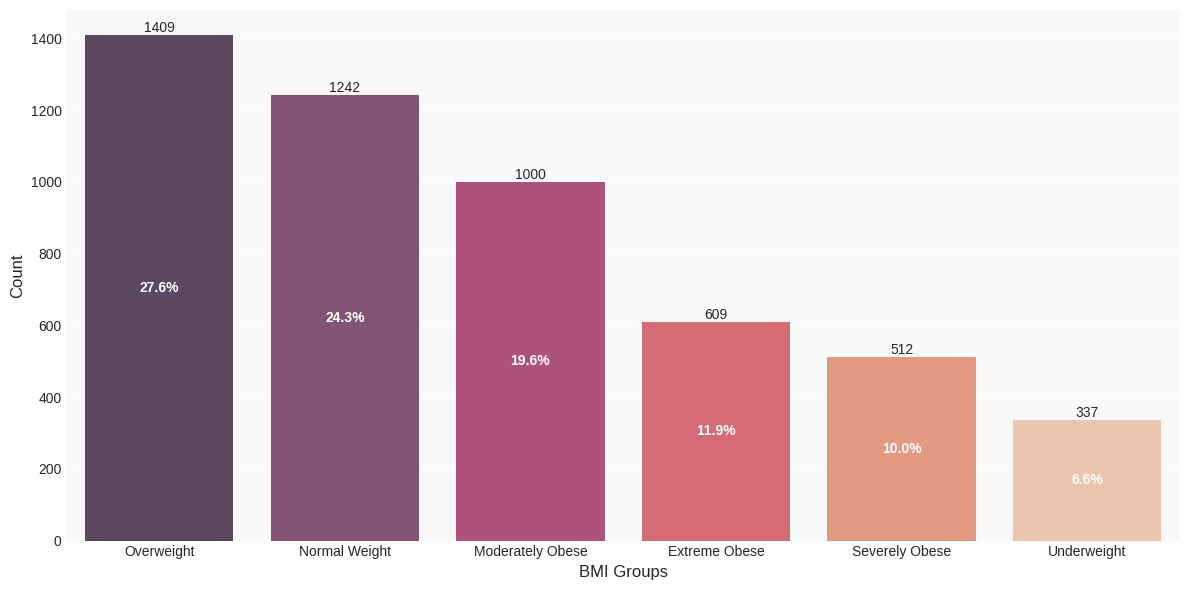

In [63]:
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(12, 6))

bmi_counts = heartdf['BMI_Group'].value_counts()
ax = sns.barplot(x=bmi_counts.index,
                 y=bmi_counts.values,
                 palette='rocket',
                 alpha=0.8)

plt.xlabel('BMI Groups', fontsize=12)
plt.ylabel('Count', fontsize=12)

for i, v in enumerate(bmi_counts.values):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=10)

ax.grid(axis='y', linestyle='--', alpha=0.7)


plt.xticks(rotation=0)


ax.set_facecolor('#f8f9fa')


total = bmi_counts.sum()
for i, v in enumerate(bmi_counts.values):
    percentage = (v/total) * 100
    ax.text(i, v/2, f'{percentage:.1f}%',
            ha='center',
            va='center',
            color='white',
            fontweight='bold')

plt.tight_layout()

plt.show()